### Create the MIST Geometry Using Techniques from `planning.ipynb`

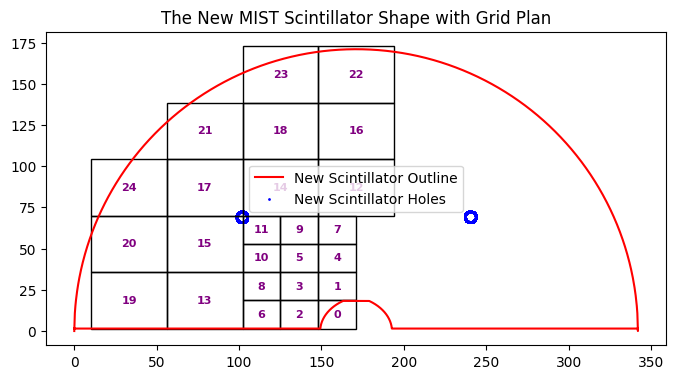

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

line1 = [np.linspace(0,171-21.75,1000),np.full(1000,1.5)]
xi,yi = -np.sqrt(21.75**2-1.5**2), 1.5
xf,yf = 171-15.69/2,18.3
line2 = [np.linspace(171+xi,xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(xi,-np.sqrt(21.75**2-18.3**2),1000)])]
line3 = [np.linspace(xf,171+15.69/2,1000),np.full(1000,yf)]

xf,yf = np.sqrt(21.75**2-1.5**2), 1.5
xi,yi = 171+15.69/2,18.3
line4 = [np.linspace(xi,171+xf,1000),np.array([np.sqrt(21.75**2-x**2) for x in np.linspace(np.sqrt(21.75**2-18.3**2),xf,1000)])]
line5 = [np.linspace(171+21.75,342,1000),np.full(1000,1.5)]

line6 = [np.linspace(0,342,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(-171,171,1000)])]

new_scint = np.concatenate((line1, line2, line3, line4, line5, np.flip(line6, axis=1)), axis=1)

r = 3.3
circ = np.transpose(np.array([r * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)


fig, ax = plt.subplots(figsize=(8, 8))
patches = []

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(171/height)
cols = round(342/width)
centring_correction = (cols*width - 342)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        # Determine if we are in the middle-third horizontally and bottom-third vertically
        if (col > cols/centre_range and col < (round(centre_range/2))*cols/centre_range) and (row < rows/centre_range):
            
            # Base offsets for this specific grid cell
            x_base = col * width - centring_correction
            y_base = row * height + 1.5
            
            w_sub = width / 2
            h_sub = height / 2
            
            # Bottom-left sub-rectangle
            patches.append(Rectangle((x_base, y_base), w_sub, h_sub))
            # Bottom-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base), w_sub, h_sub))
            # Top-left sub-rectangle
            patches.append(Rectangle((x_base, y_base + h_sub), w_sub, h_sub))
            # Top-right sub-rectangle
            patches.append(Rectangle((x_base + w_sub, y_base + h_sub), w_sub, h_sub))
        else:
            patches.append(Rectangle((col * width - centring_correction, row * height + 1.5), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([171, 1.5]), 170
new_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    if x_c > 171:
        continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    new_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

# Sort by distance from target center
new_box_data.sort(key=lambda item: item['distance'])

# --- 3. PLOT AND LABEL ---
plt.title("The New MIST Scintillator Shape with Grid Plan")
plt.plot(new_scint[0], new_scint[1], label="New Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="New Scintillator Holes", s=1, color='blue')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(new_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

30


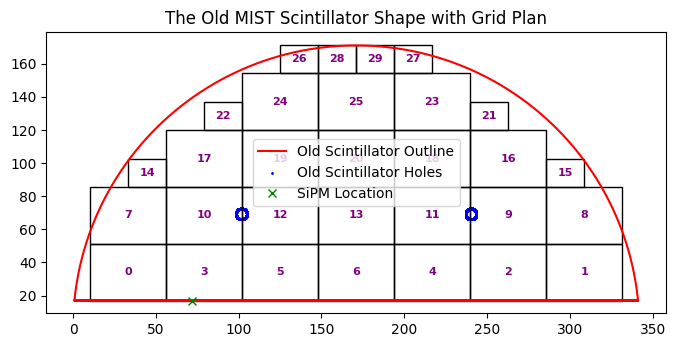

In [13]:
def circle(radius):
   return np.transpose(np.array([radius * np.array([np.cos(theta), np.sin(theta)]) for theta in np.linspace(0, 2*np.pi, 1000)]))

R = 171
h = 17

xi,xf = -np.sqrt(R**2-h**2) + R, np.sqrt(R**2-h**2) + R, 
line1 = [np.linspace(xi,xf,1000),np.full(1000,h)]

line2 = [np.linspace(xi,xf,1000),np.array([np.sqrt(171**2-x**2) for x in np.linspace(xi-R,xf-R,1000)])]

old_scint = np.concatenate((line1, line2), axis=1)

circ = circle(3.3)
line7 = circ + np.transpose(np.full((1000, 2), [171-69.3, 69.3]))
line8 = circ + np.transpose(np.full((1000, 2), [171+69.3, 69.3]))

holes = np.concatenate((line7, line8), axis=1)

SiPM_loc = [65+7,h]

fig, ax = plt.subplots(figsize=(8, 8))
patches = []

R,h = 171, 17

tolerance = 0.9
scale_factor = 0.75

width = 22.96
height = 17.14
centre_range = 4

# Base large dimensions
width *= 2
height *= 2

rows = round(R/height)
cols = round(2*R/width)
centring_correction = (cols*width - 2*R)/2

# --- 1. POPULATE PATCHES WITH CORRECT COORDINATE MATH ---
for row in range(rows):
    for col in range(cols):
        x,y = col * width - centring_correction, row * height + h
        x_c = x + width / 2
        y_c = y + height / 2
        dist = np.linalg.norm([x_c,y_c] - target_center)
        if dist>tolerance*R:
            if col == int(cols/2):
                patches.append(Rectangle((x,y), width/2, height/2))
                patches.append(Rectangle((x+width/2,y), width/2, height/2))
            elif x < R:
                patches.append(Rectangle((x+width/2,y), width/2, height/2))
            else:
                patches.append(Rectangle((x,y), width/2, height/2))
        else:
            patches.append(Rectangle((x,y), width, height))

# --- 2. FILTER AND TRACK DYNAMIC DIMENSIONS ---
target_center, target_range = np.array([R, 0]), R-1
old_box_data = []

for patch in patches:
    # Safely extract the custom width and height of THIS specific rectangle
    w = patch.get_width()
    h = patch.get_height()
    
    x, y = patch.get_xy()
    x_c = x + w / 2
    y_c = y + h / 2
    x_shift = x + w

    # Out of circular boundary check
    if np.linalg.norm(np.array([x_c, y_c]) - target_center) > target_range:
        continue
    # Bottom cutout check
    if y == 1.5 and (x > 171-21.75 and x < 171+21.75) and (x_shift > 171-21.75 and x_shift < 171+21.75):
        continue
    # Right-hand side removal constraint
    # if x_c > 171:
    #     continue

    # Calculate distance for sorting
    distance = np.linalg.norm(np.array([x_c, y_c]) - target_center)
    
    old_box_data.append({
        'xy': (x, y),
        'w': w,
        'h': h,
        'centre': (x_c, y_c),
        'distance': distance
    })

print(len(old_box_data))

# Sort by distance from target center
# box_data.sort(key=lambda item: item['distance'], reverse=True)
old_box_data.sort(key=lambda item: (item['xy'][1], -item['distance']))

# Make scaled down model
tc_col = target_center.reshape(2, 1)
scaled_scint = tc_col + scale_factor * (old_scint - tc_col)
scaled_holes = tc_col + scale_factor * (holes - tc_col)

# --- 3. PLOT AND LABEL ---
plt.title("The Old MIST Scintillator Shape with Grid Plan")
plt.plot(old_scint[0], old_scint[1], label="Old Scintillator Outline", color='red')
plt.scatter(holes[0], holes[1], label="Old Scintillator Holes", s=1, color='blue')
plt.plot(SiPM_loc[0],SiPM_loc[1],marker='x',linestyle='',label="SiPM Location",color='green')

# Redraw the filtered patches using their unique stored sizes
for box_id, data in enumerate(old_box_data):
    x, y = data['xy']
    w, h = data['w'],data['h']
    x_c, y_c = data['centre']
    
    # Draw the rectangle with its exact individual size
    rect = Rectangle((x, y), w, h, facecolor='none', edgecolor='black')
    ax.add_patch(rect)
    
    # Place text exactly at the calculated center
    ax.text(x_c, y_c, str(box_id), color='purple', fontsize=8,
            ha='center', va='center', weight='bold')

ax = plt.gca()
ax.set_aspect('equal')
plt.legend()
plt.show()

### Detection Efficiency as a Function of Position in the MIST
A little more work, but fairly important

### Timing Resolution
A little more work, not that necessary (basically bonus)